# SHAP

In [ ]:
import xarray as xr
import pandas as pd

from pkg.shap.kernel_shap import run_kernel_shap
from pkg.plots.shap_plots import plot_shap_feature_importance, compare_mean_wind_speed_input_climatology


In [2]:
input_path="../data/graphcast_small/graphcast_small_zeynep_input/graphcast_ready_input_graphcast_small_zeynep_input.nc"
climate_path="../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"

input_ds = xr.open_dataset(input_path)
climatology_ds = xr.open_dataset(climate_path)

### Run SHAP

In [ ]:
variables = [
    "2m_temperature",
    ("10m_u_component_of_wind", "10m_v_component_of_wind"),
    "total_precipitation_6hr",
    "mean_sea_level_pressure",
    "temperature",
    ("u_component_of_wind", "v_component_of_wind"),
    "geopotential",
    "vertical_velocity",
    "specific_humidity",
]

shap_df = run_kernel_shap(
    features=variables,
    input_ds=input_ds,
    climatology_ds=climatology_ds,
    shap_folder="../data/shap/variables_100samples",
    nsamples=100
)

### Analyse Results

Difference between 10 m wind speed input and 10 m wind speed climatology should be the sum of all shapley values.

In [4]:
# show results

shap_df_path = "../data/shap/variables_100samples/shap_values.csv"
shap_df = pd.read_csv(shap_df_path)

print("SHAP values for each feature:")
print(shap_df)

# sum all shap values
shap_sum = shap_df["shap_value"].sum()
print("\nSum of SHAP values:")
print(shap_sum)

# wind speed of climatology and prediction
print("\nMean wind speed in North Germany:")

compare_mean_wind_speed_input_climatology(
    input_ds=input_ds,
    climatology_ds=climatology_ds,
    lat_bounds=(53.0, 55.0),  # North Germany
    lon_bounds=(8.0, 10.0)  # North Germany
)

SHAP values for each feature:
                                           feature  shap_value
0                                   2m_temperature   -1.128868
1  10m_u_component_of_wind+10m_v_component_of_wind    1.092064
2                          total_precipitation_6hr   -0.577163
3                          mean_sea_level_pressure    0.416519
4                                      temperature   -1.021452
5          u_component_of_wind+v_component_of_wind    8.081312
6                                     geopotential    1.083176
7                                vertical_velocity   -1.409706
8                                specific_humidity   -0.439337

Sum of SHAP values:
6.09654426574707

Mean wind speed in North Germany:
North Germany mean 10 m wind at last time (input)      : 14.723 m/s
North Germany mean 10 m wind at last time (climatology): 1.540 m/s


{'input_mean_wind_speed': 14.722603797912598,
 'climatology_mean_wind_speed': 1.5396076440811157}

### Plot Values

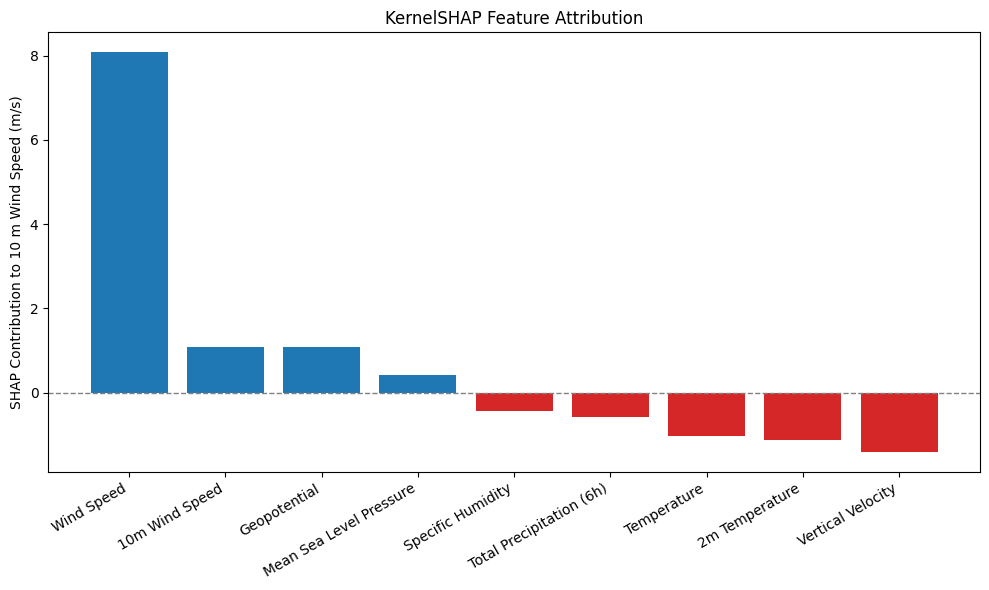

In [3]:
# plot results
plot_shap_feature_importance(shap_df_path)